# Unemployment Analysis with Python

## Oasis Infobyte Data Science Internship

### Task 2

**Author:** Harshit Raj Gupta


## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on unemployment data in India to identify regional and temporal trends. The project also analyzes the impact of the COVID-19 pandemic on unemployment rates using data visualization and statistical analysis.

## Import Required Libraries

The following libraries are imported for data manipulation, visualization, and data analysis.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

The unemployment dataset is loaded into a pandas DataFrame for further analysis.

In [31]:
from google.colab import files

uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India (1).csv


In [32]:
import os

print(os.listdir("/content"))

['.config', 'Unemployment in India.csv', 'Unemployment in India (1).csv', 'sample_data']


In [33]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Data Cleaning

The dataset contains extra spaces in some column names. These spaces are removed to make the column names consistent and easier to use in analysis.

In [34]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

## Data Inspection

The dataset is inspected to understand its dimensions, structure, data types, missing values, and summary statistics before performing exploratory data analysis.

In [35]:
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 7)


In [36]:
df.dtypes

,0
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [37]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [38]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Date Conversion

The Date column is converted from text format to datetime format to enable time-series analysis and month-wise trend visualization.

In [39]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df.dtypes

,0
Region,object
Date,datetime64[ns]
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps identify patterns, trends, and relationships in the unemployment dataset using statistical summaries and visualizations.

## Region-wise Average Unemployment Rate

The average unemployment rate is calculated for each region to identify areas with relatively higher unemployment.

In [40]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

region_avg

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


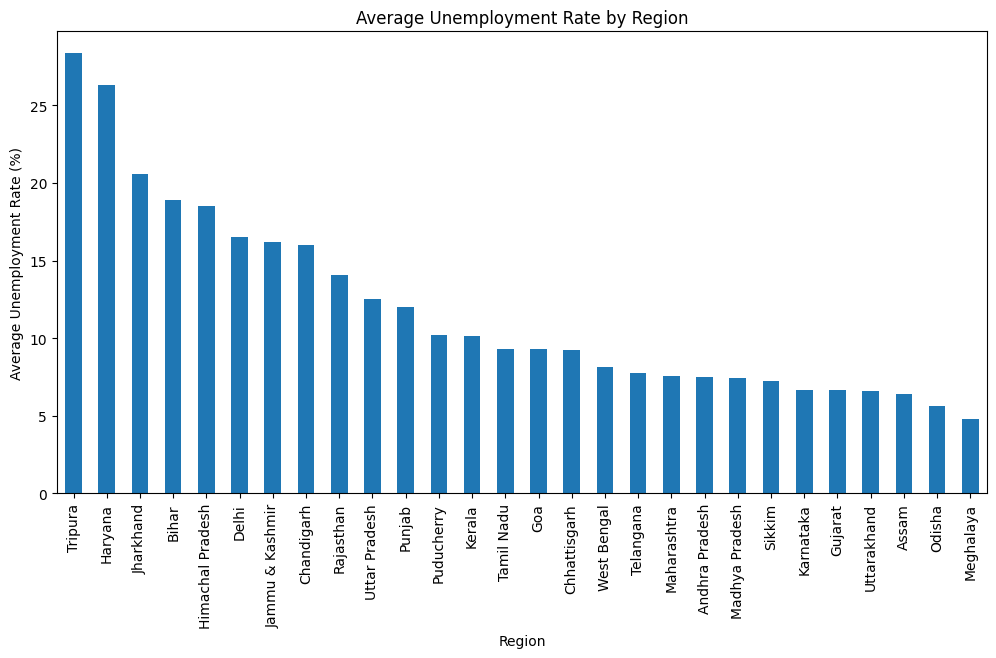

In [41]:
plt.figure(figsize=(12,6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")

plt.xlabel("Region")

plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.show()

### Observation

The bar chart shows the average unemployment rate across different regions of India. Regions with taller bars have experienced higher average unemployment compared to others.

## Month-wise Unemployment Trend

The unemployment trend is analyzed month by month to understand how unemployment changed over time.

In [42]:
df["Month"] = df["Date"].dt.month_name()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September


In [43]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

month_avg = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
      .mean()
      .reindex(month_order)
)

month_avg

,Estimated Unemployment Rate (%)
Month,
January,9.950755
February,9.964717
March,10.700577
April,23.641569
May,16.646190
June,10.553462
July,9.033889
August,9.637925
September,9.051731


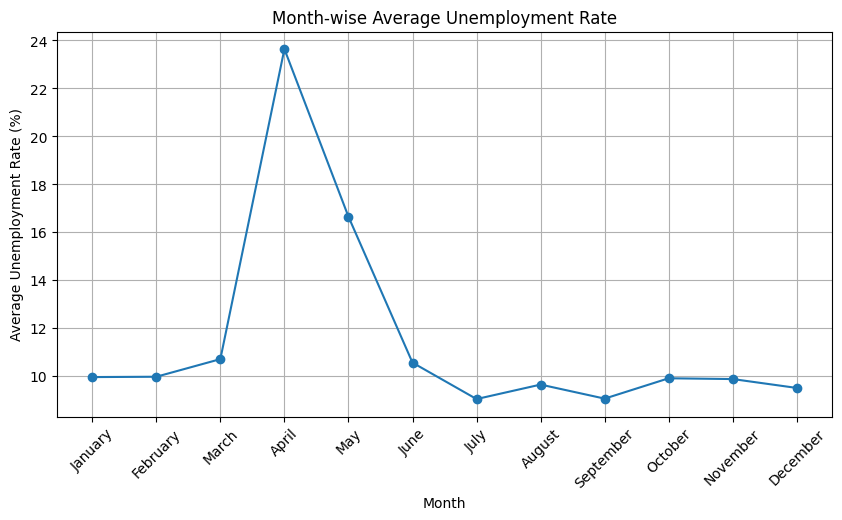

In [44]:
plt.figure(figsize=(10,5))

plt.plot(
    month_avg.index,
    month_avg.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Month-wise Average Unemployment Rate")

plt.xlabel("Month")

plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.show()

### Observation

The line chart illustrates how the average unemployment rate changes across different months. Peaks indicate months with relatively higher unemployment, while lower points represent periods of reduced unemployment.

## Time-Series Analysis

A time-series analysis is performed for three major states to visualize how unemployment rates changed over time.

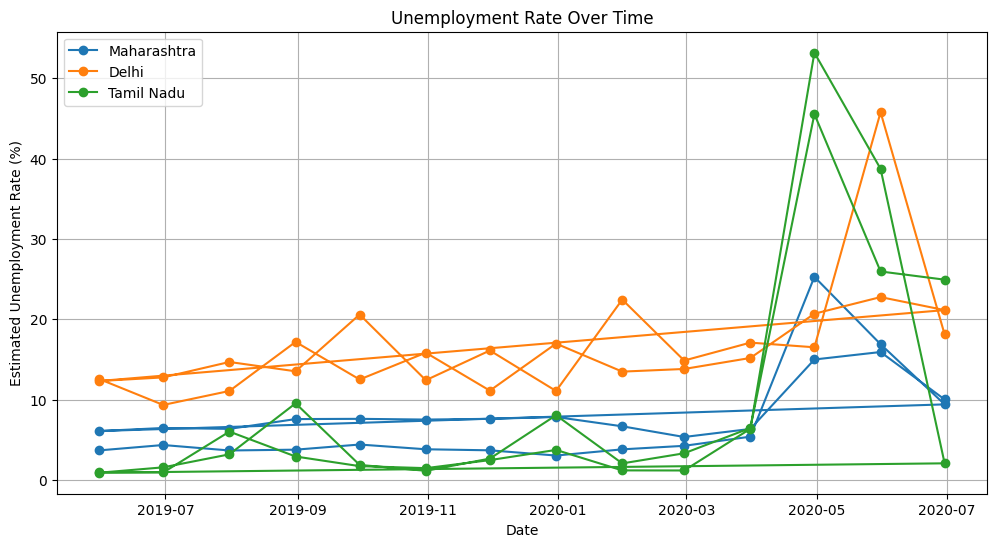

In [45]:
# Select three major states
states = ["Maharashtra", "Delhi", "Tamil Nadu"]

state_data = df[df["Region"].isin(states)]

plt.figure(figsize=(12,6))

for state in states:
    temp = state_data[state_data["Region"] == state]
    plt.plot(
        temp["Date"],
        temp["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The line chart compares unemployment trends over time for three major states. It highlights how unemployment levels changed during different periods and allows comparison between states.

## Top 10 States with Highest Average Unemployment Rate

The average unemployment rate for each state is calculated and the top 10 states are visualized using a bar chart.

In [46]:
top10 = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top10

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


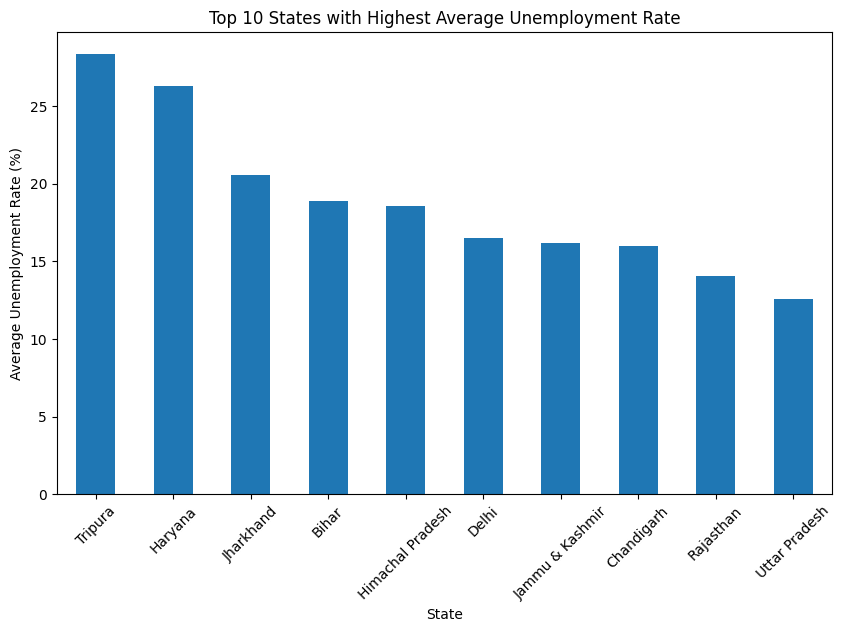

In [47]:
plt.figure(figsize=(10,6))

top10.plot(kind="bar")

plt.title("Top 10 States with Highest Average Unemployment Rate")

plt.xlabel("State")

plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Observation

The chart highlights the ten states with the highest average unemployment rates, indicating the regions that were most affected during the study period.

## Correlation Analysis

A heatmap is used to understand the relationship between unemployment rate, employment, and labour participation rate.

In [48]:
correlation = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

correlation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


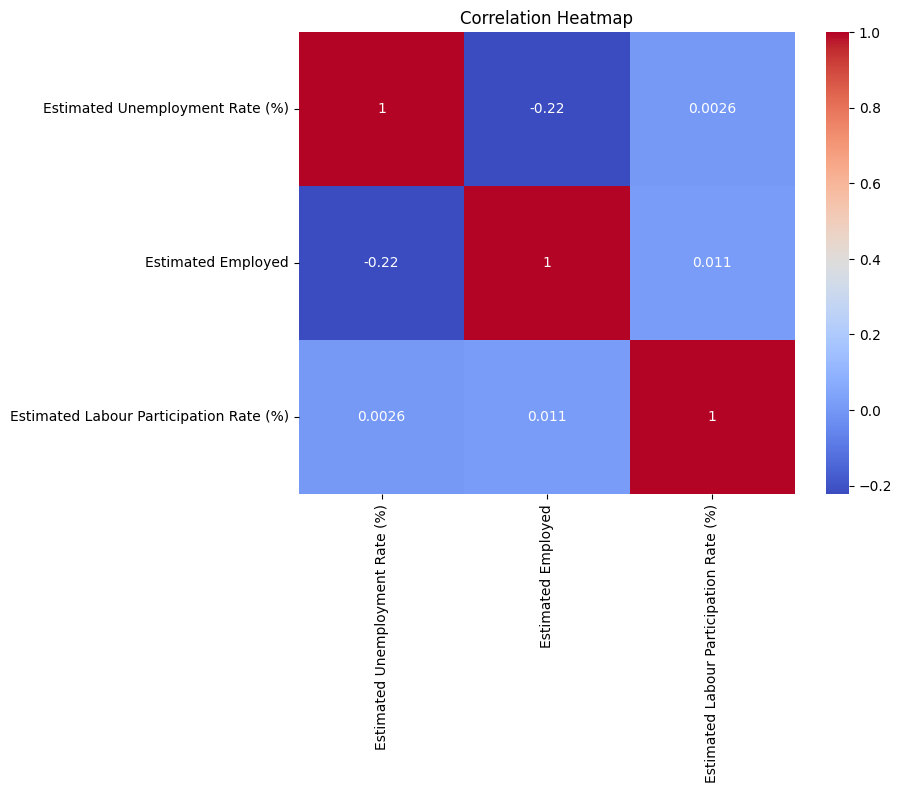

In [49]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap illustrates the correlation between unemployment rate, employment, and labour participation rate. Positive and negative correlations indicate how these variables are related.

# Pre-COVID vs Post-COVID Analysis

The COVID-19 pandemic significantly affected employment across India. This section compares the average unemployment rate before and after the pandemic.

In [50]:
covid_date = "2020-03-25"

pre_covid = df[df["Date"] < covid_date]

post_covid = df[df["Date"] >= covid_date]

In [51]:
comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate (%)": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Unemployment Rate (%)"].mean()
    ]
})

comparison

,Period,Average Unemployment Rate (%)
0,Pre-COVID,9.509534
1,Post-COVID,17.774363


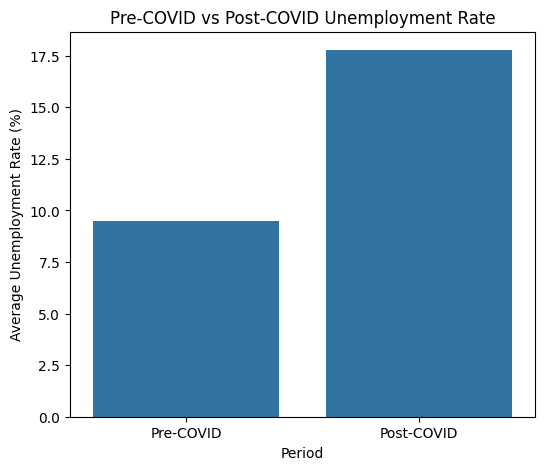

In [52]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate (%)"
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")

plt.ylabel("Average Unemployment Rate (%)")

plt.show()

### Observation

The comparison shows the change in average unemployment rate before and after the COVID-19 pandemic. A higher post-COVID unemployment rate indicates the significant economic impact of the pandemic on employment.

# Conclusion

This project analyzed unemployment trends in India using Python.

Key findings include:

- The dataset was successfully cleaned and analyzed.
- Regional differences in unemployment rates were observed.
- Monthly unemployment trends showed noticeable fluctuations.
- The top 10 regions with the highest average unemployment were identified.
- Correlation analysis explained the relationship between unemployment, employment, and labour participation.
- The comparison between the pre-COVID and post-COVID periods highlighted the impact of the pandemic on unemployment levels.

Overall, this project demonstrates the use of Python, Pandas, Matplotlib, and Seaborn for exploratory data analysis and data visualization.